In [1]:
from scipy.optimize import least_squares

In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

# Cumulative and Differential Data Sets

In [4]:
df_cumulative_Chen = pd.DataFrame({
    "S" : np.array([0.19, 0.32, 0.52, 0.86, 1.43, 2.36, 3.91, 6.47]),
    "N"    : np.array([92, 84, 69, 53, 39, 25, 13, 4]),
    "dN/dS": [21900, 12950, 7390, 4120, 2660, 1540, 770, 230],
    "dN/dS err lower": [3250, 1640, 930, 560, 420, 300, 210, 110], 
    "dN/dS err upper": [3250, 1640, 930, 560, 420, 370, 270, 180]
})

df_cumulative_Chen[""] = ["|" for S in df_cumulative_Chen["S"]]


df_cumulative_Chen

,S,N,dN/dS,dN/dS err lower,dN/dS err upper,
0,0.19,92,21900,3250,3250,|
1,0.32,84,12950,1640,1640,|
2,0.52,69,7390,930,930,|
3,0.86,53,4120,560,560,|
4,1.43,39,2660,420,420,|
5,2.36,25,1540,300,370,|
6,3.91,13,770,210,270,|
7,6.47,4,230,110,180,|


In [5]:
df_diff_Chen = pd.DataFrame({
    "S": [0.25, 0.42, 0.69, 1.15, 1.90, 3.14, 5.19],
    "N": np.array([8, 15, 16, 14, 14, 12, 9]),
    "dN/dS": [73860, 28600,  10230,  2780, 1280, 530, 220], # Units of mJy^-1 deg^-2
    "dN/dS err lower": [29940, 8210, 2670, 740, 340, 150, 70], 
    "dN/dS err upper": [39660, 10180, 3350, 960, 440, 200, 100]
})


df_diff_Chen[""] = ["|" for S in df_diff_Chen["S"]]


df_diff_Chen

,S,N,dN/dS,dN/dS err lower,dN/dS err upper,
0,0.25,8,73860,29940,39660,|
1,0.42,15,28600,8210,10180,|
2,0.69,16,10230,2670,3350,|
3,1.15,14,2780,740,960,|
4,1.90,14,1280,340,440,|
5,3.14,12,530,150,200,|
6,5.19,9,220,70,100,|


# Completeness and Area

I am taking my completeness data from Figure 4 in https://iopscience.iop.org/article/10.3847/0004-637X/822/1/36/pdf

I am just looking at their plot and taking data points - estimate and not exact

In [6]:
sf = 0.25 / 4

complete_SNR = np.arange(2, 10.5, 0.5) - sf

complete_percent = [1, 1, 4, 13, 17, 35, 50, 65, 80, 90, 100, 100, 100, 100, 100, 100, 100]

In [7]:
# # Create interpolation function
# interp_func = interp1d(complete_SNR, complete_percent, kind='linear', bounds_error=False, fill_value=(complete_percent[0], complete_percent[-1]))

In [8]:
# Create interpolation function (linear)
interp_func = interp1d(
    complete_SNR, 
    complete_percent, 
    kind='linear', 
    bounds_error=False, 
    fill_value=(complete_percent[0], complete_percent[-1])
)


# Create a dense array of SNR values for plotting
SNR_dense = np.linspace(complete_SNR[0]-0.5, complete_SNR[-1]+0.5, 500)
percent_dense = interp_func(SNR_dense)


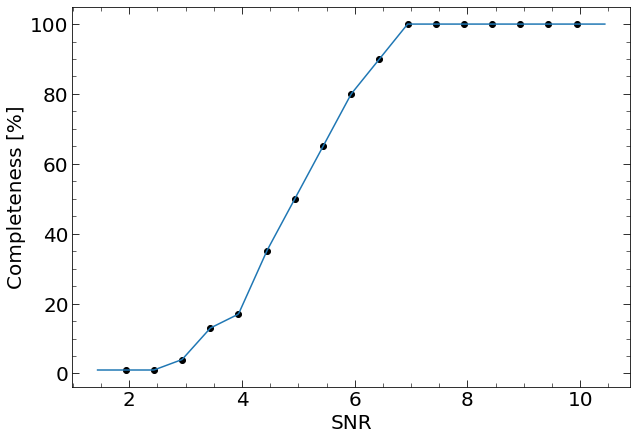

In [9]:
# make the figures
fig, ax = plt.subplots(1, 1, figsize=(10, 7))


# Plot data on left plot
ax.scatter(complete_SNR, complete_percent, color = 'black', ls = '-', label=f'label')

plt.plot(SNR_dense, percent_dense, '-', label='Interpolated')

# Add axis labels
ax.set_xlabel(r'SNR', fontsize=axis_label_fs)
ax.set_ylabel('Completeness [%]', fontsize = axis_label_fs)


# Adjust ticks
ax.minorticks_on()
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

ax.tick_params(axis="x", which="minor", direction="in", bottom=True, top=True, length=4, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4, labelsize=axis_num_fs)


# Effective area

In [10]:
sensitivity = [0, 0.0625, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2]

effective_area = [1e-2, 1e-1, 5, 20, 30, 30, 30, 30, 35, 40]

In [11]:
# Create interpolation function (linear)
area_interp_func = interp1d(
    sensitivity, 
    effective_area, 
    kind='quadratic', 
    bounds_error=False, 
    fill_value=(effective_area[0], effective_area[-1])
)


# Create a dense array of SNR values for plotting
sensitivity_dense = np.linspace(sensitivity[0]-0.5, sensitivity[-1]+0.5, 500)
effective_area_dense = area_interp_func(sensitivity_dense)


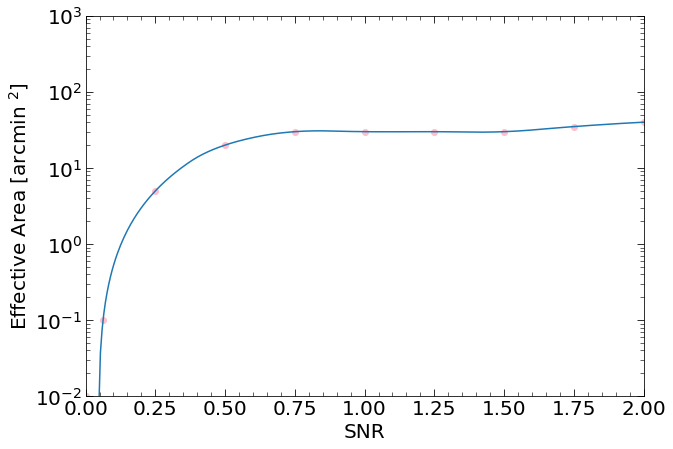

In [12]:
# make the figures
fig, ax = plt.subplots(1, 1, figsize=(10, 7))


# Plot data on left plot
ax.scatter(sensitivity, effective_area, color = 'pink', ls = '-')

plt.plot(sensitivity_dense, effective_area_dense, '-', label='Interpolated')

# Add axis labels
ax.set_xlabel(r'SNR', fontsize=axis_label_fs)
ax.set_ylabel('Effective Area [arcmin $^2$]', fontsize = axis_label_fs)


# Adjust ticks
ax.minorticks_on()
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

ax.tick_params(axis="x", which="minor", direction="in", bottom=True, top=True, length=4, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4, labelsize=axis_num_fs)

ax.set_ylim(1e-2, 1e3)
ax.set_xlim(0, 2)

ax.set_yscale("log")

# Total Cumulative Number Count

In [13]:
def number_count_cumulative(S_mJy):
    
    # Note: Top fraction is 1- f_sp, but f_sp = 0 
    
    A = area_interp_func(S_mJy)/ 3600 # arcmin squared 

    
    # https://iopscience.iop.org/article/10.3847/0004-637X/822/1/36/pdf
    # "The 30 ALMA maps in our sample have a resolution of
    #   0″. 35 × 0″. 25, and median noise of 0.21 mJy beam−1"
    
    # Function reads in S/N
    C = interp_func(S_mJy / 0.21)
    
    Ni_Si = 1 / (C * A)
    
    return Ni_Si

# Calculate N diff

$\frac{dN_j}{dS} = \frac{\sum_i^{n_{ij}}N_i}{S_{j+1}-S_j}$

In [14]:
dN_dS = []

for j in range(len(df_diff_Chen)):
    
    S_diff = df_cumulative_Chen["S"][j+1] -  df_cumulative_Chen["S"][j]
    
    N_sum = np.sum(df_diff_Chen["N"][:j+1])

    
    dN_dS_j = N_sum / S_diff
    
    dN_dS.append(dN_dS_j)
    
    

    
df_diff_Chen["dN/dS .C"] = dN_dS

df_diff_Chen

,S,N,dN/dS,dN/dS err lower,dN/dS err upper,,dN/dS .C
0,0.25,8,73860,29940,39660,|,61.538462
1,0.42,15,28600,8210,10180,|,115.000000
2,0.69,16,10230,2670,3350,|,114.705882
3,1.15,14,2780,740,960,|,92.982456
4,1.90,14,1280,340,440,|,72.043011
5,3.14,12,530,150,200,|,50.967742
6,5.19,9,220,70,100,|,34.375000


# Fit the values from the paper

## Functions

In [15]:
from scipy.special import gammaincc, gamma
from scipy.integrate import quad


# def schechter_cum(params, S):
#     alpha, S0, N0 = params
#     Sgrid = np.linspace(S, 100, 1000)   # integrate from S to 100 mJy
#     return np.trapz(schechter_diff([alpha,S0,N0], Sgrid), Sgrid)

# def dpl_cum(params, S):
#     alpha, beta, S0, N0 = params
#     Sgrid = np.linspace(S, 100, 1000)
#     return np.trapz(dpl_diff([alpha,beta,S0,N0], Sgrid), Sgrid)


def log_residual(params, func, x, y):
    # pass params as a single array (do NOT unpack)
    model = np.array([func(params, xi) for xi in x])
    mask = (model > 0) & (y > 0)
    return np.log10(model[mask]) - np.log10(y[mask])



def log_residual_asym(params, model, x, y, yerr_lower, yerr_upper):
    y_model = model(x, params)  # now order matches
    residuals = np.log10(y) - np.log10(y_model)
    
    sigma = np.where(y_model > y, yerr_upper, yerr_lower)
    sigma_log = sigma / (y * np.log(10))
    
    return residuals / sigma_log



### Schechter

Equation (4):


$N(>S) dS = N_0 \left(\frac{S}{S_0}\right)^\alpha \exp \left(\frac{S}{S_0}\right) d \left(\frac{S}{S_0}\right)$

In [16]:
def Schechter(S, params):
    
    alpha, S0, N0 = params
    
    return (N0 / S0) * (S/S0)**alpha * np.exp(-S/S0)


### Double power-law

Equation (5):

$N(>S) dS = N_0 \left[\left(\frac{S}{S_0}\right)^\alpha + \left(\frac{S}{S_0}\right)^\beta \right]^{-1} d \left(\frac{S}{S_0}\right)$

In [17]:
def DoublePowerLaw(S, params):
    alpha, beta, S0, N0 = params
    return (N0* 3600/S0) * ((S/S0)**alpha + (S/S0)**beta)**-1

## Do the fit

least_squares reads in:
 - function
 - x0: arrap of initial guess on independent variables
- args: the x and y data 


The guesses will be the results from the paper

In [18]:
# Differential Schechter (alpha, S0, N0)
Schechter_Diferential_Guess = [-1.7, 3.9, 2.2]

# Differential DPL (alpha, beta, S0, N0)
DoublePowerLaw_Diferential_Guess = [2.0, 4.7, 5.6, 0.8]

# Cumulative Schechter (alpha, S0, N0)
Schechter_Cumulative_Guess = [-0.6, 2.2, 9.6]

# Cumulative DPL (alpha, beta, S0, N0)
DoublePowerLaw_Cumulative_Guess = [1.0, 4.7, 4.5, 3.6]

In [19]:
# # 1. Differential Schechter
# results1 = least_squares(log_residual, Schechter_Diferential_Guess,
#                              args=(Schechter, df_diff_Chen["S"], df_diff_Chen["dN/dS"]))



# results2 = least_squares(log_residual, DoublePowerLaw_Diferential_Guess,
#                              args=(DoublePowerLaw, df_diff_Chen["S"], df_diff_Chen["dN/dS"]),
#                             bounds=([0, 0, 0, 0], [np.inf, np.inf, np.inf, np.inf]))  # all > 0)




# # 3. Cumulative Schechter
# results3 = least_squares(log_residual, Schechter_Cumulative_Guess,
#                             args=(Schechter, df_cumulative_Chen["S"], df_cumulative_Chen["dN/dS"]))



# # 4. Cumulative DPL
# results4 = least_squares(log_residual, DoublePowerLaw_Cumulative_Guess,
#                             args=(DoublePowerLaw, df_cumulative_Chen["S"], df_cumulative_Chen["dN/dS"]),
#                             bounds=([0, 0, 0, 0], [np.inf, np.inf, np.inf, np.inf]))  # all > 0)

In [20]:
yerr_lower_diff = df_diff_Chen["dN/dS err lower"]
yerr_upper_diff = df_diff_Chen["dN/dS err upper"]

yerr_lower_cum = df_cumulative_Chen["dN/dS err lower"]
yerr_upper_cum = df_cumulative_Chen["dN/dS err upper"]


In [21]:
# --- Differential Schechter ---
results1 = least_squares(
    log_residual_asym,
    Schechter_Diferential_Guess,
    args=(Schechter, df_diff_Chen["S"], df_diff_Chen["dN/dS"],
          df_diff_Chen["dN/dS err lower"], df_diff_Chen["dN/dS err upper"])
)

# --- Differential Double Power Law ---
results2 = least_squares(
    log_residual_asym,
    DoublePowerLaw_Diferential_Guess,
    args=(DoublePowerLaw, df_diff_Chen["S"], df_diff_Chen["dN/dS"],
          df_diff_Chen["dN/dS err lower"], df_diff_Chen["dN/dS err upper"]),
    bounds=([0,0,0,0],[np.inf,np.inf,np.inf,np.inf])
)

# --- Cumulative Schechter ---
results3 = least_squares(
    log_residual_asym,
    Schechter_Cumulative_Guess,
    args=(Schechter, df_cumulative_Chen["S"], df_cumulative_Chen["dN/dS"],
          df_cumulative_Chen["dN/dS err lower"], df_cumulative_Chen["dN/dS err upper"])
)



# --- Cumulative Double Power Law ---
results4 = least_squares(
    log_residual_asym,
    DoublePowerLaw_Cumulative_Guess,
    args=(DoublePowerLaw, df_cumulative_Chen["S"], df_cumulative_Chen["dN/dS"],
          df_cumulative_Chen["dN/dS err lower"], df_cumulative_Chen["dN/dS err upper"]),
    bounds=([0,0,0,0],[np.inf,np.inf,np.inf,np.inf])
)


In [22]:
S_grid = np.linspace(0.05, 30, 1000)

# Evaluate best-fit models
schechter_fit_diff = Schechter(S_grid, results1.x) * S_grid**2.5
dpl_fit_diff       = DoublePowerLaw(S_grid, results2.x) * S_grid**2.5

schechter_fit_diff_paper = Schechter(S_grid, Schechter_Diferential_Guess) * S_grid**2.5

# Evaluate best-fit models
schechter_fit_cumulative = Schechter(S_grid, results3.x)


# schechter_fit_cumulative_paper = Schechter(S_grid, Schechter_Cumulative_Guess) 


schechter_fit_cumulative_paper = Schechter(S_grid, Schechter_Cumulative_Guess) 

dpl_fit_cumulative       = DoublePowerLaw(S_grid, results4.x) 

In [23]:
# Print resilts
print("\n===== FIT RESULTS =====")


print("Differential Schechter: alpha = %.3f, S0 = %.3g, N0 = %.3g" %
      tuple(results1.x))
print(" ")

print("Differential DPL:       alpha = %.3f, beta = %.3f, S0 = %.3g, N0 = %.3g" %
      tuple(results2.x))
print(" ")

print("Cumulative Schechter:   alpha = %.3f, S0 = %.3g, N0 = %.3g" %
      tuple(results3.x))
print(" ")

print("Cumulative DPL:         alpha = %.3f, beta = %.3f, S0 = %.3g, N0 = %.3g" %
      tuple(results4.x))
print(" ")


===== FIT RESULTS =====
Differential Schechter: alpha = -1.946, S0 = 1.84e+04, N0 = 0.447
 
Differential DPL:       alpha = 1.946, beta = 1.946, S0 = 4.74, N0 = 0.616
 
Cumulative Schechter:   alpha = -1.008, S0 = 12.1, N0 = 4.02e+03
 
Cumulative DPL:         alpha = 1.064, beta = 5.889, S0 = 6.19, N0 = 0.925
 


(0.1, 100000.0)

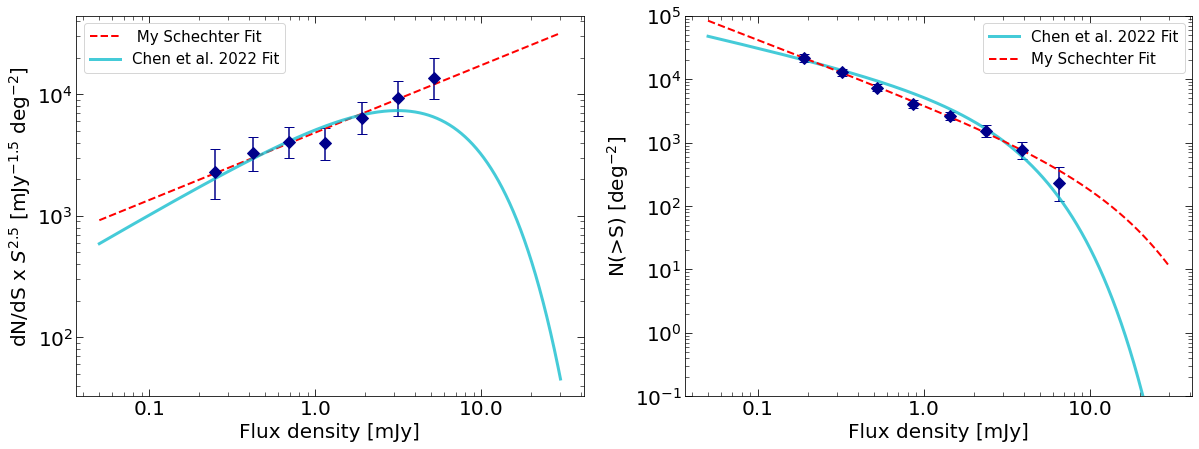

In [24]:
# make the figures
fig, ax = plt.subplots(1, 2, figsize=(20, 7))


# Left plot
# ------------------------------------------------------------------------------------
# Compute the lower and upper errors on the y-values
yerr_lower_diff = df_diff_Chen["dN/dS err lower"] * df_diff_Chen["S"]**2.5
yerr_upper_diff = df_diff_Chen["dN/dS err upper"] * df_diff_Chen["S"]**2.5

# Error bars want a 2D array for asymmetric case: [[lower_errors], [upper_errors]]
yerr_diff = np.array([yerr_lower_diff, yerr_upper_diff])


# Plot with error bars
ax[0].errorbar(
    df_diff_Chen["S"],
    df_diff_Chen["dN/dS"] * df_diff_Chen["S"]**2.5,
    yerr=yerr_diff,
    fmt='D',             # diamond marker
    color='darkblue',
    markersize=8,
    capsize=5,           # little horizontal bar at the ends
    elinewidth=1.5
)

ax[0].plot(S_grid, schechter_fit_diff, color='red', ls = '--', lw=2, label=' My Schechter Fit')
# ax[0].plot(S_grid, dpl_fit_diff, color='green', lw=2, ls='--', label='DPL fit')

ax[0].plot(S_grid, schechter_fit_diff_paper* 1.15e3, color='tab:cyan', alpha = 0.8,  lw=3,  label='Chen et al. 2022 Fit')


# ------------------------------------------------------------------------------------




# Right plot
# ------------------------------------------------------------------------------------
# Compute the lower and upper errors on the y-values
yerr_lower_cumulative = df_cumulative_Chen["dN/dS err lower"]
yerr_upper_cumulative = df_cumulative_Chen["dN/dS err upper"]

# Error bars want a 2D array for asymmetric case: [[lower_errors], [upper_errors]]
yerr_cumulative = np.array([yerr_lower_cumulative, yerr_upper_cumulative])


# Plot with error bars
ax[1].errorbar(
    df_cumulative_Chen["S"],
    df_cumulative_Chen["dN/dS"],
    yerr=yerr_cumulative,
    fmt='D',             # diamond marker
    color='darkblue',
    markersize=8,
    capsize=5,           # little horizontal bar at the ends
    elinewidth=1.5
)



ax[1].plot(S_grid, schechter_fit_cumulative_paper * 1.15e3, color='tab:cyan', alpha = 0.8,  lw=3, label='Chen et al. 2022 Fit')



ax[1].plot(S_grid, schechter_fit_cumulative, color='red', lw=2, ls = '--', label='My Schechter Fit')
# ax[1].plot(S_grid, dpl_fit_cumulative, color='green', lw=2, ls='--', label='DPL fit')
# ------------------------------------------------------------------------------------






# Set y-axis labels 
ax[0].set_ylabel('dN/dS x $S^{2.5}$ [mJy$^{-1.5}$ deg$^{-2}$]', fontsize = axis_label_fs)
ax[1].set_ylabel('N(>S) [deg$^{-2}$]',  fontsize = axis_label_fs)


# Add an x-label, proper ticks on axes and add a legend
for i in range(2):

    # Add axis labels
    ax[i].set_xlabel(r'Flux density [mJy]', fontsize=axis_label_fs)


    # Adjust ticks
    ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
        
    ax[i].tick_params(axis="x", which="minor", direction="in", bottom=True, top=True, length=4, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4, labelsize=axis_num_fs)

    ax[i].legend(fontsize = legend_text_fs)
    
    ax[i].set_xscale("log")
    ax[i].set_yscale("log")
    
    ax[i].xaxis.set_major_formatter(ScalarFormatter())
    ax[i].ticklabel_format(axis="x", style="plain")

# ax[0].set_ylim(1e2, 1e5) 
# ax[0].set_xlim(0.07, 30) 

ax[1].set_ylim(1e-1, 1e5)
# ax[1].set_xlim(0.03, 50)


# mine, paper, paper 10^3

In [25]:
def schechter(s, a=0, S0=1, N0=1):
    return N0*3600/S0*(s/S0)**(a+1)*np.exp(-s/S0)

(0.1, 100000)

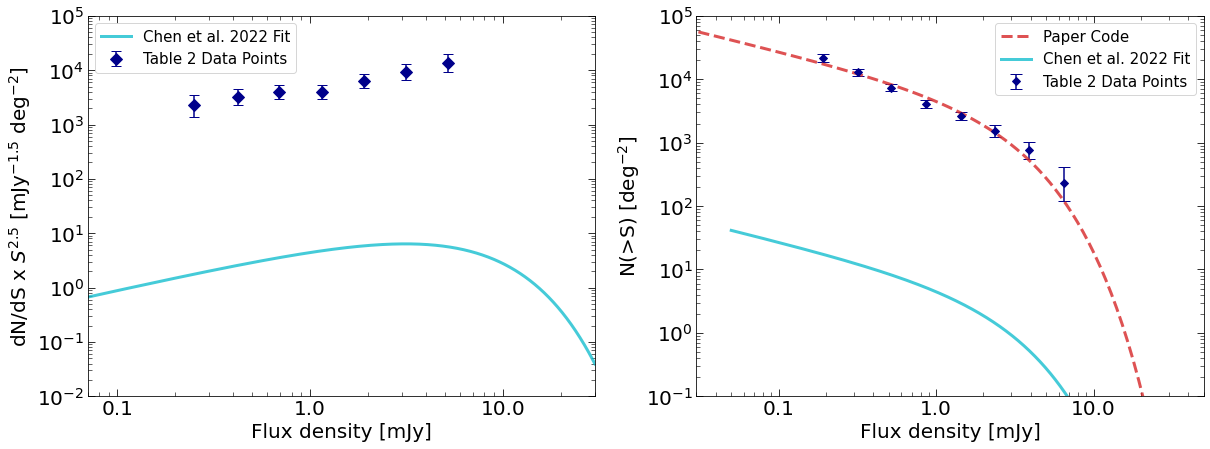

In [27]:
# make the figures
fig, ax = plt.subplots(1, 2, figsize=(20, 7))


# Left plot
# ------------------------------------------------------------------------------------
# Compute the lower and upper errors on the y-values
yerr_lower_diff = df_diff_Chen["dN/dS err lower"] * df_diff_Chen["S"]**2.5
yerr_upper_diff = df_diff_Chen["dN/dS err upper"] * df_diff_Chen["S"]**2.5

# Error bars want a 2D array for asymmetric case: [[lower_errors], [upper_errors]]
yerr_diff = np.array([yerr_lower_diff, yerr_upper_diff])


# Plot with error bars
ax[0].errorbar(
    df_diff_Chen["S"],
    df_diff_Chen["dN/dS"] * df_diff_Chen["S"]**2.5,
    yerr=yerr_diff,
    fmt='D',             # diamond marker
    color='darkblue',
    markersize=8,
    capsize=5,           # little horizontal bar at the ends
    elinewidth=1.5,
    label ='Table 2 Data Points'
)

# ax[0].plot(S_grid, schechter_fit_diff, color='red', lw=2, label=' My Schechter Fit')
# ax[0].plot(S_grid, dpl_fit_diff, color='green', lw=2, ls='--', label='DPL fit')

ax[0].plot(S_grid, schechter_fit_diff_paper, color='tab:cyan', alpha = 0.8,  lw=3, label='Chen et al. 2022 Fit')


# ------------------------------------------------------------------------------------




# Right plot
# ------------------------------------------------------------------------------------
# Compute the lower and upper errors on the y-values
yerr_lower_cumulative = df_cumulative_Chen["dN/dS err lower"]
yerr_upper_cumulative = df_cumulative_Chen["dN/dS err upper"]

# Error bars want a 2D array for asymmetric case: [[lower_errors], [upper_errors]]
yerr_cumulative = np.array([yerr_lower_cumulative, yerr_upper_cumulative])


# Plot with error bars
ax[1].errorbar(
    df_cumulative_Chen["S"],
    df_cumulative_Chen["dN/dS"],
    yerr=yerr_cumulative,
    fmt='D',             # diamond marker
    color='darkblue',
    markersize=6,
    capsize=6,           # little horizontal bar at the ends
    elinewidth=1.5,
    label ='Table 2 Data Points'
)


B7_schechter_sols = [-1.6,  2.2,  2.67] # [alpha-1, S0, N0]

B7_flux_fitted = np.logspace(-2, 1.5, 100)
ax[1].plot(B7_flux_fitted, 
        schechter(B7_flux_fitted, *B7_schechter_sols), 
        linewidth=3., 
        alpha=0.8, 
        color='tab:red', 
        label='Paper Code',
          ls = '--') 

ax[1].plot(S_grid, schechter_fit_cumulative_paper, color='tab:cyan', alpha = 0.8, lw=3, label='Chen et al. 2022 Fit')



# ax[1].plot(S_grid, schechter_fit_cumulative, color='red', lw=2, label='My Schechter Fit')
# ax[1].plot(S_grid, dpl_fit_cumulative, color='green', lw=2, ls='--', label='DPL fit')
# ------------------------------------------------------------------------------------






# Set y-axis labels 
ax[0].set_ylabel('dN/dS x $S^{2.5}$ [mJy$^{-1.5}$ deg$^{-2}$]', fontsize = axis_label_fs)
ax[1].set_ylabel('N(>S) [deg$^{-2}$]',  fontsize = axis_label_fs)


# Add an x-label, proper ticks on axes and add a legend
for i in range(2):

    # Add axis labels
    ax[i].set_xlabel(r'Flux density [mJy]', fontsize=axis_label_fs)


    # Adjust ticks
    ax[i].minorticks_on()
    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)
        
    ax[i].tick_params(axis="x", which="minor", direction="in", bottom=True, top=True, length=4, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4, labelsize=axis_num_fs)

    ax[i].legend(fontsize = legend_text_fs)
    
    ax[i].set_xscale("log")
    ax[i].set_yscale("log")
    
    ax[i].xaxis.set_major_formatter(ScalarFormatter())
    ax[i].ticklabel_format(axis="x", style="plain")

    
# Left plot bounds   
# ------------------------
# Paper
# ax[0].set_xlim(0.06, 30)
# ax[0].set_ylim(5., 1e5)
# ------------------------
# Mine
ax[0].set_ylim(1e-2, 1e5) 
ax[0].set_xlim(0.07, 30)
# ------------------------


# ax[0].set_ylim(1e-2, 1e5) 
# # ax[0].set_xlim(0.07, 30) 

# Right plot bounds
# ------------------------
# Paper
ax[1].set_xlim(0.03, 50)
ax[1].set_ylim(0.1, 10**5)
# ------------------------
# Mine
# ------------------------
# ax[1].set_ylim(1e-7, 1e5)
# ax[1].set_xlim(0.03, 50)


# mine, paper, paper 10^3